### Train a Classifier
1. Define the NN
2. Define the Loss
3. Train: Forward pass, backward pass using `loss.backward()` , weight update

### Data
* Image, text, audio, video
* Load the data into numpy array using standard python package and then convert them to `torch.*Tensor`
* Pillow, OpenCV for images
* scipy and librosa for audio
* raw Python, Cython, NLTK and SpaCy for text
* `torchvision` package provides dataloaders for common datasets such as ImageNet, CIFAR10, MNIST and data transforms for images and viz., `torchvision.datasets`, `torch.utils.data.DataLoader` - avoids boilerplate code


CIFAR10 Dataset
* CIFAR10 dataset has $10$ labels
  * airplane
  * automobile
  * bird
  * cat
  * deer
  * dog
  * frog 
  * horse
  * ship
  * truck
* The size of each image is $3 \times 32 \times 32$ that is 3 channel color images of $32 \times 32$ pixel size.

### Training an image classifier

1. Load and normalize the CIFAR10 train and test datasets using `torchvision`
2. Define a Convolutional Neural Network (CNN)
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data.

### Load and Noramalize CIFAR10


In [23]:
import torch
import torchvision
from torchvision.transforms import v2

The output of torchvision datasets are **PILImages** of range $[0, 1]$. We transform them to Tensors of normalized range $[-1, 1]$.


**Iterable** is a behavior or protocol; an object is iterable if Python can loop over it. Dataloader is a class whose objects are iterable. `__iter__` is a special Python method that makes an object **iterable**.
* Called when `iter(obj)` or `for x in obj:`.
* It must return an **iterator** (an object with `__next__`).
1. *Preferred: define `__iter__` (return an operator)*
````python
class MyCollection:
    def __init__(self, data):
        self.data = data

    def __iter__(self):
        return iter(self.data) # delegates to list operator

obj = MyCollection([10, 20, 30])
for x in obj:
    print(x)
````
2. *Custom iterator object: define both `__iter__` and `__next__`*
````python
class CountUpTo:
    def __init__(self, n):
        self.n = n
        self.i = 0

    def __iter__(self):
        return self
    
    def __next__(self):
        if self.i >= self.n:
            raise StopIteration
        val = self.i
        self.i += 1
        return val

for x in CountUpTo(3):
    print(x) # 0, 1, 2, 3
````
3. *Easiest: use a generator in `__iter__`*
```python
class Squares:
    def __init__(self, n):
        self.n = n
    def __iter__(self):
        for i in range(self.n):
            yield i * i
```

In [24]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='../data', train= True,
                                        download = True, transform = transform)
trainloader = torch.utils.data.DataLoader(dataset = trainset, batch_size= batch_size,
                                          shuffle= True, num_workers= 2)

testset = torchvision.datasets.CIFAR10(root='../data', train= False, 
                                       download = True, transform= transform)
testloader = torch.utils.data.DataLoader(dataset= testset, batch_size= batch_size,
                                         shuffle= True, num_workers= 2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')



Let us show some training images for fun.

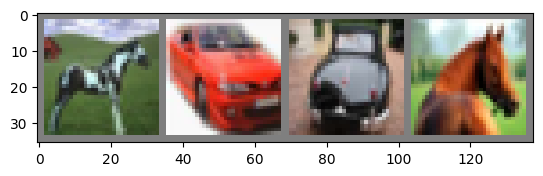

horse car   car   horse


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show images
def imshow(img):
    img = img / 2 + 0.5 # unnormalize: The normalization is  x_norm=(x - mu_x)/std_x
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [26]:
print(images[1].shape)

torch.Size([3, 32, 32])


## Define a Convolutional Neural Network
I would like to practice writng the network class. 

In [27]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # out dim per image channel is  (32 - 5 + 1 = 28) 28 x 28
        self.conv2 = nn.Conv2d(6, 16, 5) # out dim
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.out = nn.Linear(84, 10)

    def forward(self, x):
        # Convolutional Layer C1: out_dim -> (N x 6 x 14 x 14)
        c1 = F.max_pool2d(F.relu(self.conv1(x)), 2) 
        # Convolutional Layer C2: out_dim -> (N x 16 x 5 x 5)
        c2 = F.max_pool2d(F.relu(self.conv2(c1)), 2)
        # flatten operation F3: out_dim -> (16 x 5 x 5 = 400)
        fl3 = torch.flatten(c2, 1)
        # Fully Connected Linear Layer F4: out_dim -> (120)
        f4 = F.relu(self.fc1(fl3))
        # Fully Connected Linear Layer F5: out_dim(84)
        f5= F.relu(self.fc2(f4))
        # Output layer y: out_dim -> (10)
        y = self.out(f5)
        return y
    

net = Net()

### Define a Loss Function and optimizer
Use a Classification Cross-Entropy loss and SGD with momentum

In [28]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

#### Train the Network
* Loop over our data iterator
* Feed the inputs to the network
* Optimize

In [29]:
for epoch in range(2): # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward
        outputs = net(inputs)

        # evaluate error
        loss = criterion(outputs, labels)

        # backward
        loss.backward()

        # update weight
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i%2000 == 1999: # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')


KeyboardInterrupt: 

Save the trained model

In [ ]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

### Test the Network on Test Data

Load the earlier trained `cifar_net.pth`

In [ ]:
net = Net()
PATH = './cifar_net.pth'
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

Display an image from the testset to get familiar

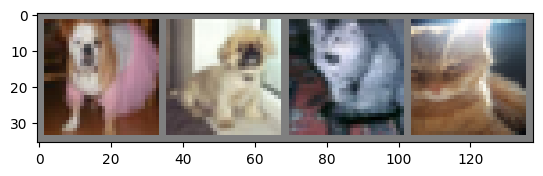

GroundTruth:  dog   dog   cat   cat  
torch.Size([4])


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
print(labels.size())

Let's check the NN output for the above images

In [ ]:
outputs = net(images)
print(outputs)

tensor([[ 1.0233,  1.4453,  0.9916,  1.7447, -1.1555,  0.2813, -2.1223, -0.5680,
         -0.6711, -0.6762],
        [-2.3646, -2.8872,  0.6762,  3.3072,  0.8103,  2.8255,  0.5460, -0.7209,
         -0.5143, -2.6201],
        [ 3.1591, -2.1102,  2.0027,  1.5763,  0.0469, -0.1459, -0.2432, -1.3234,
         -0.3033, -1.9609],
        [-2.1715, -2.3523,  0.6255,  2.4565,  0.6495,  1.1561,  2.0874, -0.7496,
         -1.1758, -1.1619]], grad_fn=<AddmmBackward0>)


Seems like each image has 10 output corresponding to output dimension of NN. These outputs are called energies for the 10 classes. The higher the energy for a class, the more the network thinks that the image is of particular class. Let's get the index of the highest energy.

In [ ]:
_, predicted = torch.max(outputs, 1)
#print(_, predicted)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  cat   cat   plane cat  


So, the result is $50 \%$. Garbage!

Let us look at how the network performs on the whole dataset.


In [ ]:
correct = 0
total = 0

# Since this is just evalation of the network, gradient calculation is not required.abs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        out = net(images)
        _, predicted = torch.max(out, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy of network on the 10000 test images: {100 * correct // total} %')
        

Accuracy of network on the 10000 test images: 54 %


See which classes performed well and which did not!

In [37]:
# Make a dictionary for counting predictions of each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
with torch.no_grad():
    for data in testloader:
        images, labels = data
        out = net(images)
        _, predictions = torch.max(out, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1
        
# print accuracy for each of the classes
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 0.0 %
Accuracy for class: car   is 0.6 %
Accuracy for class: bird  is 0.0 %
Accuracy for class: cat   is 0.0 %
Accuracy for class: deer  is 0.0 %
Accuracy for class: dog   is 0.0 %
Accuracy for class: frog  is 0.0 %
Accuracy for class: horse is 99.3 %
Accuracy for class: ship  is 0.0 %
Accuracy for class: truck is 0.0 %


#### Training on GPU
Just like tensor is transferred to GPU, the neural net is transferred onto the GPU.
Define our device as first visible CUDA device if CUDA is available

In [39]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')
print(device)

cuda


In [ ]:
net.to(device)

Remember that the inputs and targets have to be sent to GPU at each step. I think it means each batch has to be explicitely sent to GPU.

In [ ]:
inputs, labels = data[0].to(device), data[1].to(device)

Why do not I see massive speedup compared to CPU? Because the Network is too small.

#### **Goal Achieved**

* Understanding PyTorch's tensor library and neural networks at an implementation level
* Training a small network for image classification and its details.